In [13]:
from feos import * #EquationOfState, State, Contributions
from feos.parameters import * #Parameters, PureRecord, Identifier

import si_units as si

import matplotlib as mpl
import matplotlib.pyplot as plt


# Dimensioned (methanol)

In [14]:
# Lafitte Methanol parameters

methanol_saft_vr_mie = {
    "identifier": Identifier(name="methanol"),
    "molarweight": 32.026,
    "m": 1.5283,
    "sigma": 3.3063,
    "epsilon_k": 167.72,
    "rep": 8.6556,
    "att": 6.0,
    "association_sites": [
      {
        "na": 1.0,
        "nb": 1.0,
        "rc_ab": 0.41314,
        "rd_ab": 0.4,
        "epsilon_k_ab": 2904.7
      }
    ]
}

pr = PureRecord(**methanol_saft_vr_mie)
parameters = Parameters.new_pure(pr)

model = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y"
)

temperature = 2.0 * 167.72 * si.KELVIN
density = 100 * si.MOL / si.METER**3
state = State(model, temperature=temperature, density=density)

for n, c in state.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")
    #print(f"{n:<30}: {c}")

Hard Sphere (WCA, TPT)        :   0.00947711
Mie Chain                     :  -0.00055710
Reference Perturbation (WCA)  :   0.00085121
Attractive Perturbation (WCA) :  -0.02223419
Association                   :  -0.50703205


[crates/feos/src/uvtheory/eos/mod.rs:336:9] rc = 1.365964782
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rd = 1.32252
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rmin = 2.64504
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rmax = 4.011004782
[crates/feos/src/uvtheory/eos/mod.rs:336:9] sigma_ij = 3.3063
[crates/feos/src/uvtheory/eos/mod.rs:336:9] &state.partial_density = VecStorage {
    data: [
        6.0221407600000015e-5,
    ],
    nrows: Dyn(
        1,
    ),
    ncols: Const,
}
[crates/feos/src/uvtheory/eos/mod.rs:336:9] state.temperature = 335.44
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rho_st = 0.003326490494855135
[crates/feos/src/uvtheory/eos/mod.rs:336:9] width = 0.6829823909999999
[crates/feos/src/uvtheory/eos/mod.rs:336:9] i_ab_ij = 2.356159125104078
[crates/feos/src/uvtheory/eos/mod.rs:336:9] f_ab = 5762.918192193566
[crates/feos/src/uvtheory/eos/mod.rs:336:9] delta = 13578.352285765168


In [ ]:
phase_diagram = PhaseDiagram.pure(model, 180 * si.KELVIN, 25)

# Reduced

In [5]:
reduced = {
    "identifier": Identifier(),
    "molarweight": 1.0,
    "m": 1.0,
    "sigma": 1.0,
    "epsilon_k": 1.0,
    "rep": 12.0, 
    "att": 6.0,
    "association_sites": [
      {
        "na": 1.0,
        "nb": 1.0,
        "rc_ab": 0.2,
        "rd_ab": 0.4,
        "epsilon_k_ab": 10.0
      }
    ]
}

pr = PureRecord(**reduced)
parameters = Parameters.new_pure(pr)
model = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y"
)

density = 0.15 / si.ANGSTROM**3 / si.NAV
temperature=2.0 * si.KELVIN

state = State(model, temperature=temperature, density=density)
for n, c in state.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")

Hard Sphere (WCA, TPT)        :   0.31388301
Mie Chain                     :   0.00000000
Reference Perturbation (WCA)  :   0.02291829
Attractive Perturbation (WCA) :  -0.51821650
Association                   :  -0.07611322


[crates/feos/src/uvtheory/eos/mod.rs:336:9] rc = 0.2
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rd = 0.4
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rmin = 0.8
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rmax = 1.0
[crates/feos/src/uvtheory/eos/mod.rs:336:9] sigma_ij = 1.0
[crates/feos/src/uvtheory/eos/mod.rs:336:9] &state.partial_density = VecStorage {
    data: [
        0.15,
    ],
    nrows: Dyn(
        1,
    ),
    ncols: Const,
}
[crates/feos/src/uvtheory/eos/mod.rs:336:9] state.temperature = 2.0
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rho_st = 0.15
[crates/feos/src/uvtheory/eos/mod.rs:336:9] width = 0.09999999999999998
[crates/feos/src/uvtheory/eos/mod.rs:336:9] i_ab_ij = 0.0037110603987921364
[crates/feos/src/uvtheory/eos/mod.rs:336:9] f_ab = 147.4131591025766
[crates/feos/src/uvtheory/eos/mod.rs:336:9] delta = 0.5470591370064166


In [ ]:
phase_diagram = PhaseDiagram.pure(model, 1 * si.KELVIN, 100)

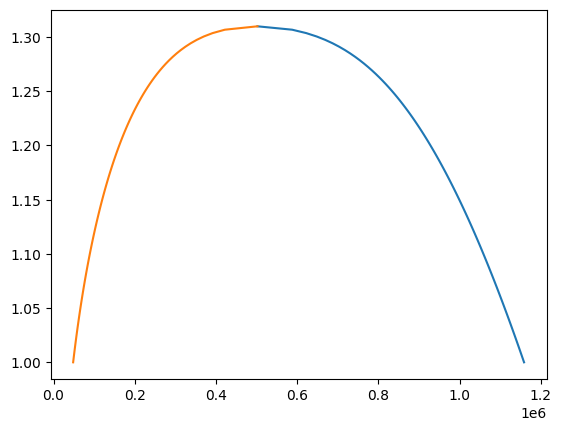

In [8]:
plt.plot(phase_diagram.liquid.density / (si.MOL/si.METER**3), 
         phase_diagram.liquid.temperature / si.KELVIN, '-')
plt.plot(phase_diagram.vapor.density / (si.MOL/si.METER**3), 
         phase_diagram.vapor.temperature / si.KELVIN, '-')